In [35]:
import os
import pandas as pd
import librosa
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

In [36]:
AUDIO_PATH = "train"
CSV_PATH = "train.csv"
SAMPLE_RATE = 22050
N_MELS = 128
DURATION = 5
N_CLASSES = 42

In [37]:
def audio_to_mel_spectrogram(file_path, sr=SAMPLE_RATE, n_mels=N_MELS, duration=DURATION):
    y, _ = librosa.load(file_path, sr=sr, duration=duration)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    return mel_spec_db

class BirdSoundDataset(Dataset):
    def __init__(self, csv_path, audio_path, transform=None):
        self.data = pd.read_csv(csv_path)
        self.audio_path = audio_path
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        file_path = os.path.join(self.audio_path, row['filename'])
        label = row.iloc[1:].values.astype(np.float32)
        mel_spec = audio_to_mel_spectrogram(file_path)
        if self.transform:
            mel_spec = self.transform(mel_spec)
        return mel_spec, label

class BirdSoundTestDataset(Dataset):
    def __init__(self, audio_path, transform=None):
        self.audio_path = audio_path
        self.transform = transform
        self.file_names = os.listdir(audio_path)

    def __len__(self):
        return len(self.file_names)

    def __getitem__(self, idx):
        file_name = self.file_names[idx]
        file_path = os.path.join(self.audio_path, file_name)
        mel_spec = audio_to_mel_spectrogram(file_path)
        if self.transform:
            mel_spec = self.transform(mel_spec)
        return mel_spec, file_name


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [38]:
dataset = BirdSoundDataset("./train.csv", "./train", transform=transform)

# Sampling train dataset
# reduction_factor = 0.1
# reduced_size = int(len(dataset) * reduction_factor)
# random_indices = random.sample(range(len(dataset)), reduced_size)
# dataset = Subset(dataset, random_indices)

# Split train dataset into train dataset & validation dataset
dataset_size = len(dataset)
val_size = int(0.05 * dataset_size)
train_size = dataset_size - val_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")

Training set size: 59082
Validation set size: 3109


In [39]:
# Test dataset
test_dataset = BirdSoundTestDataset("./test", transform=transform)

# Sampling test dataset
# reduction_factor = 0.1
# reduced_size = int(len(test_dataset) * reduction_factor)
# random_indices = random.sample(range(len(test_dataset)), reduced_size)
# test_dataset = Subset(test_dataset, random_indices)

print(f"Testing set size: {len(test_dataset)}")

Testing set size: 31187


In [40]:
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=True)

In [41]:
class BirdSoundCNN(nn.Module):
    def __init__(self, n_classes):
        super(BirdSoundCNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.MaxPool2d(2, 2),
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(256 * 8 * 8, 1024),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(1024, n_classes),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = torch.flatten(x, 1)
        x = self.fc_layers(x)
        return x


In [42]:
# 7. Entrenamiento
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = BirdSoundCNN(N_CLASSES).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

In [ ]:
EPOCHS = 8
train_losses = []
val_losses = []
val_accuracies = []

print("Training...")

for epoch in range(EPOCHS):
    # Training
    model.train()
    total_train_loss = 0

    for mel_spec, labels in train_dataloader:
        mel_spec, labels = mel_spec.to(device), labels.to(device)
        optimizer.zero_grad()

        # Forward
        outputs = model(mel_spec)
        loss = criterion(outputs, labels)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_dataloader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    total_val_loss = 0
    correct_predictions = 0
    total_predictions = 0
    with torch.no_grad():
        for mel_spec, labels in val_dataloader:
            mel_spec, labels = mel_spec.to(device), labels.to(device)

            # Forward
            outputs = model(mel_spec)
            loss = criterion(outputs, labels)
            total_val_loss += loss.item()

            # Calculate accuracy
            preds = (outputs > 0.5).float()  # Umbral para considerar 1 (presente)
            correct_predictions += (preds == labels).sum().item()
            total_predictions += labels.numel()  # Número total de etiquetas

    avg_val_loss = total_val_loss / len(val_dataloader)
    val_losses.append(avg_val_loss)
    val_accuracy = correct_predictions / total_predictions
    val_accuracies.append(val_accuracy)

    torch.save(model, f"model_{epoch}.pth")

    print(f"Epoch [{epoch+1}/{EPOCHS}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")


Training...


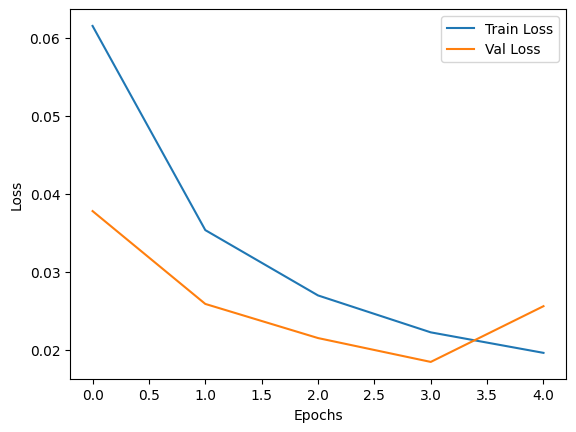

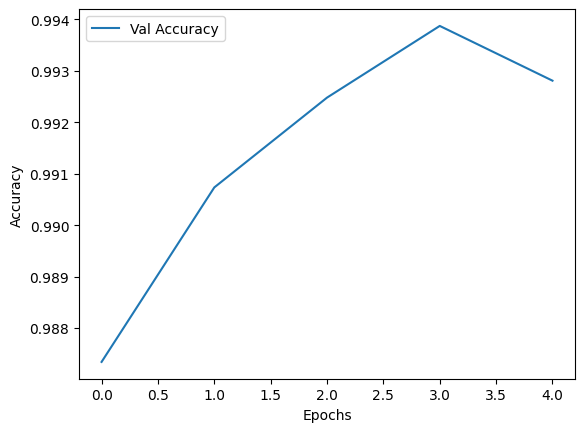

In [34]:
import matplotlib.pyplot as plt

plt.plot(range(EPOCHS), train_losses, label="Train Loss")
plt.plot(range(EPOCHS), val_losses, label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(range(EPOCHS), val_accuracies, label="Val Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [45]:
torch.backends.cudnn.benchmark = True

In [37]:
# Lista para almacenar los resultados
results = []

# Evaluar el modelo en los datos de prueba
print(len(test_dataloader))
model.eval()
with torch.no_grad():
    i = 1
    for mel_spec, file_name in test_dataloader:
        mel_spec = mel_spec.to(device)

        # Obtener las predicciones
        outputs = model(mel_spec)
        preds = (outputs > 0.5).float().cpu()  # Umbral de 0.5 para considerar presencia

        # Convertir las predicciones en índices de etiquetas activas
        for filename, pred in zip(file_name, preds):
            active_labels = [str(idx + 1) for idx, value in enumerate(pred) if value == 1]
            if not active_labels:
                active_labels = ["0"]  # Si no hay etiquetas activas

            results.append({
                "Id": filename,
                "Predicted": " ".join(active_labels)
            })
        print(i, end=" ")
        i += 1

# Guardar los resultados en un archivo CSV
output_df = pd.DataFrame(results)
output_df.to_csv("submission.csv", index=False)

print("Archivo submission.csv generado correctamente.")



1950
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246 247 248 249 250 251 252 253 254 255 256 257 258 259 260 261 262 263 264 265 266 267 268 269 270 271 272 273 274 275 276